# Camada Gold — Metricas Analiticas

A camada gold contem apenas a **OBT (One Big Table)**: join denormalizado das tres tabelas silver
na granularidade `(date, region, product)`. Todas as metricas analiticas sao calculadas a partir dela.

**Entrada:** `data/silver/` | **Saida:** `data/gold/obt.parquet`

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

ROOT = Path('..')
OBT = ROOT / 'data' / 'gold' / 'obt.parquet'

conn = duckdb.connect()
conn.execute(f"CREATE VIEW obt AS SELECT * FROM read_parquet('{OBT}')")
sns.set_theme(style='whitegrid', palette='muted')

## Dados de Entrada (Silver)

Preview dos tres datasets utilizados para calcular as metricas desta camada.

In [2]:
SILVER = ROOT / 'data' / 'silver'
for tabela in ['orders', 'production', 'inventory']:
    df = conn.execute(f"SELECT * FROM read_parquet('{SILVER}/{tabela}.parquet') LIMIT 10").df()
    print(f'\n--- {tabela} ({df.shape[1]} colunas) ---')
    print(df.to_string(index=False))


--- orders (10 colunas) ---
 order_id region product order_date requested_delivery_date actual_delivery_date  quantity  lead_time_days  delay_days  on_time
        1  LATAM       A 2023-01-01              2023-01-06           2023-01-09      1037               8           3    False
        2  LATAM       C 2023-01-01              2023-01-06           2023-01-03       845               2          -3     True
        3     NA       A 2023-01-01              2023-01-06           2023-01-13      1956              12           7    False
        4     NA       B 2023-01-01              2023-01-06           2023-01-16      1849              15          10    False
        5     NA       C 2023-01-01              2023-01-06           2023-01-13       790              12           7    False
        6     EU       A 2023-01-01              2023-01-06           2023-01-06      1719               5           0     True
        7     EU       B 2023-01-01              2023-01-06           2023-

## OTIF — On Time In Full

OTIF mede a fracao de pedidos entregues no prazo.

Pedidos com `actual_delivery_date` nulo sao contados no denominador mas nao no numerador (nao entregues no prazo).

In [3]:
resumo = conn.execute("""
    SELECT
        SUM(total_pedidos)                                              AS total_pedidos,
        SUM(pedidos_on_time)                                            AS pedidos_on_time,
        ROUND(100.0 * SUM(pedidos_on_time) / SUM(total_pedidos), 2)    AS otif_pct,
        ROUND(AVG(atraso_medio), 2)                                     AS atraso_medio_dias,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY atraso_medio)      AS atraso_mediano_dias,
        PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY atraso_medio)      AS atraso_p90_dias
    FROM obt
    WHERE total_pedidos > 0
""").df()
print(resumo.to_string(index=False))

 total_pedidos  pedidos_on_time  otif_pct  atraso_medio_dias  atraso_mediano_dias  atraso_p90_dias
        6282.0           1099.0     17.49               3.75                  2.0             10.0


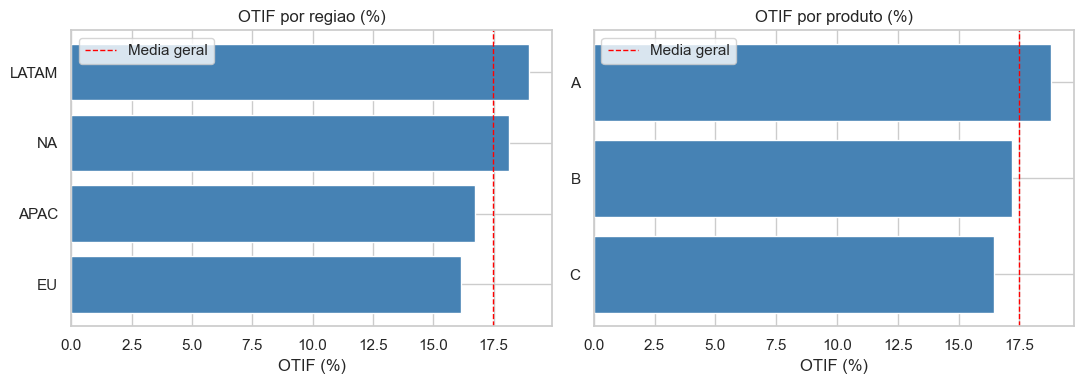

In [4]:
por_regiao = conn.execute("""
    SELECT region,
        SUM(total_pedidos) AS total_pedidos,
        SUM(pedidos_on_time) AS pedidos_on_time,
        ROUND(100.0 * SUM(pedidos_on_time) / SUM(total_pedidos), 2) AS otif_pct,
        ROUND(AVG(atraso_medio), 2) AS atraso_medio_dias
    FROM obt WHERE total_pedidos > 0
    GROUP BY region ORDER BY otif_pct
""").df()

por_produto = conn.execute("""
    SELECT product,
        SUM(total_pedidos) AS total_pedidos,
        SUM(pedidos_on_time) AS pedidos_on_time,
        ROUND(100.0 * SUM(pedidos_on_time) / SUM(total_pedidos), 2) AS otif_pct,
        ROUND(AVG(atraso_medio), 2) AS atraso_medio_dias
    FROM obt WHERE total_pedidos > 0
    GROUP BY product ORDER BY otif_pct
""").df()

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))

eixos[0].barh(por_regiao['region'], por_regiao['otif_pct'], color='steelblue')
eixos[0].axvline(resumo['otif_pct'].iloc[0], color='red', linestyle='--', linewidth=1, label='Media geral')
eixos[0].set_title('OTIF por regiao (%)')
eixos[0].set_xlabel('OTIF (%)')
eixos[0].legend()

eixos[1].barh(por_produto['product'], por_produto['otif_pct'], color='steelblue')
eixos[1].axvline(resumo['otif_pct'].iloc[0], color='red', linestyle='--', linewidth=1, label='Media geral')
eixos[1].set_title('OTIF por produto (%)')
eixos[1].set_xlabel('OTIF (%)')
eixos[1].legend()

plt.tight_layout()
plt.show()

**Interpretacao:** OTIF geral de **17,5%** e muito baixo para uma operacao de manufatura. A variacao entre regioes (EU 16,2% vs LATAM 19,2%) e pequena, o problema e sistemico, nao localizado. Produto C tem o pior desempenho.

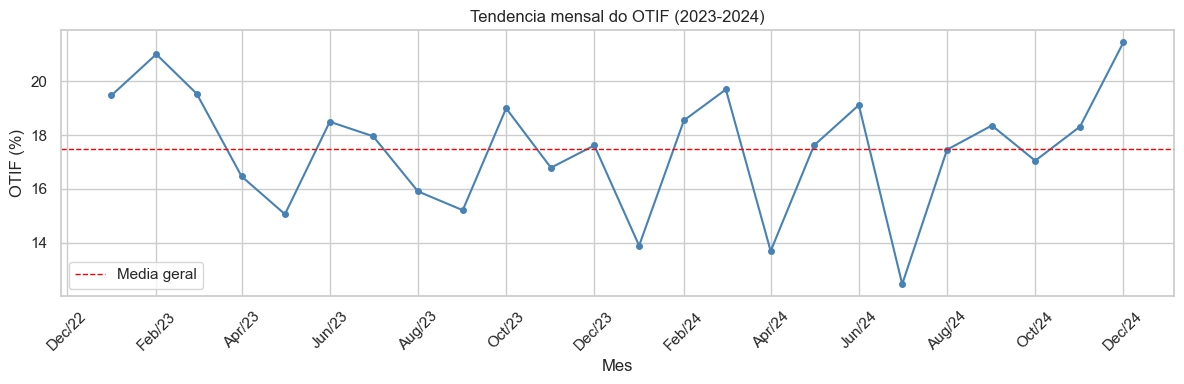

In [5]:
mensal = conn.execute("""
    SELECT
        CAST(DATE_TRUNC('month', date) AS DATE) AS mes,
        SUM(total_pedidos) AS total_pedidos,
        SUM(pedidos_on_time) AS pedidos_on_time,
        ROUND(100.0 * SUM(pedidos_on_time) / SUM(total_pedidos), 2) AS otif_pct,
        ROUND(AVG(atraso_medio), 2) AS atraso_medio_dias
    FROM obt WHERE total_pedidos > 0
    GROUP BY mes ORDER BY mes
""").df()
mensal['mes'] = pd.to_datetime(mensal['mes'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mensal['mes'], mensal['otif_pct'], marker='o', markersize=4, linewidth=1.5, color='steelblue')
ax.axhline(resumo['otif_pct'].iloc[0], color='red', linestyle='--', linewidth=1, label='Media geral')
ax.set_title('Tendencia mensal do OTIF (2023-2024)')
ax.set_xlabel('Mes')
ax.set_ylabel('OTIF (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## Estoque — Stockout e Overflow

- **Stockout:** dias com `stock_level <= 0` — risco de nao atender pedidos
- **Overflow:** dias com `stock_level > warehouse_capacity` — sobrecarga do armazem

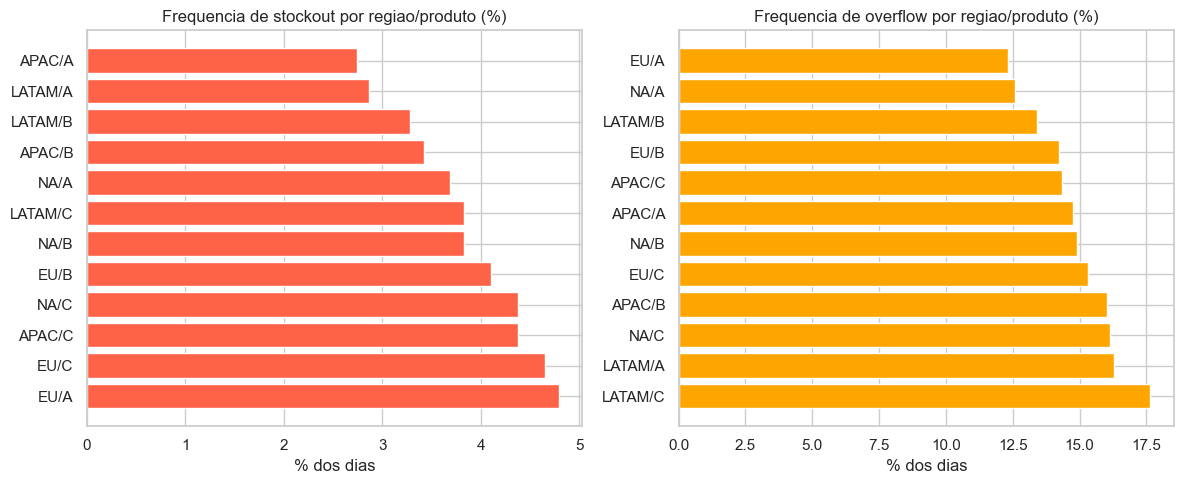

In [6]:
stockout = conn.execute("""
    SELECT region, product,
        COUNT(*) AS total_dias,
        SUM(CASE WHEN stockout_flag THEN 1 ELSE 0 END) AS dias_stockout,
        ROUND(100.0 * SUM(CASE WHEN stockout_flag THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_stockout
    FROM obt GROUP BY region, product ORDER BY pct_stockout DESC
""").df()

overflow = conn.execute("""
    SELECT region, product,
        COUNT(*) AS total_dias,
        SUM(CASE WHEN overflow_flag THEN 1 ELSE 0 END) AS dias_overflow,
        ROUND(100.0 * SUM(CASE WHEN overflow_flag THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_overflow
    FROM obt GROUP BY region, product ORDER BY pct_overflow DESC
""").df()

stockout['rotulo'] = stockout['region'] + '/' + stockout['product']
overflow['rotulo'] = overflow['region'] + '/' + overflow['product']

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

eixos[0].barh(stockout['rotulo'], stockout['pct_stockout'], color='tomato')
eixos[0].set_title('Frequencia de stockout por regiao/produto (%)')
eixos[0].set_xlabel('% dos dias')

eixos[1].barh(overflow['rotulo'], overflow['pct_overflow'], color='orange')
eixos[1].set_title('Frequencia de overflow por regiao/produto (%)')
eixos[1].set_xlabel('% dos dias')

plt.tight_layout()
plt.show()

**Interpretacao:** EU/A e EU/C lideram em dias de stockout. Simultaneamente, LATAM/C e LATAM/A apresentam os maiores indices de overflow. Isso sugere desbalanco de distribuicao entre regioes — excesso em LATAM enquanto EU enfrenta ruptura.

## Producao — Taxa de Utilizacao

Mede a eficiencia das plantas em relacao a sua capacidade declarada. Valores acima de 1.0 indicam producao acima da capacidade.

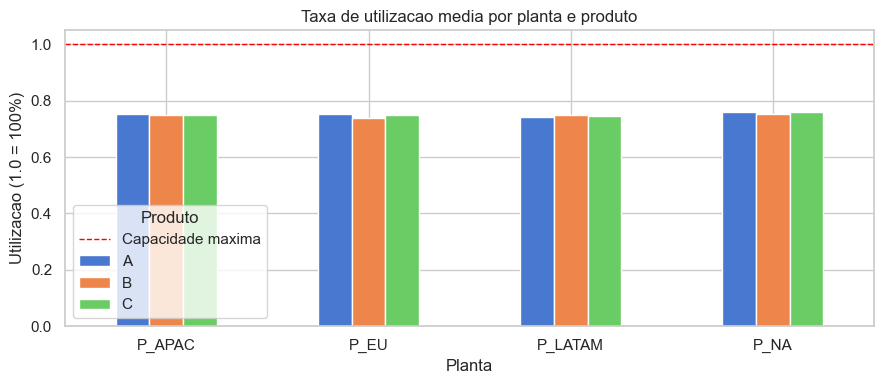


Frequencia acima da capacidade:
  plant product  pct_acima_capacidade
   P_NA       C                 23.39
   P_NA       A                 22.71
   P_EU       A                 22.98
 P_APAC       A                 19.70
   P_NA       B                 23.94
 P_APAC       B                 23.53
P_LATAM       B                 22.85
 P_APAC       C                 23.12
   P_EU       C                 22.44
P_LATAM       C                 23.67
P_LATAM       A                 20.11
   P_EU       B                 20.25


In [7]:
util_prod = conn.execute("""
    SELECT plant, region, product,
        COUNT(*) AS total_dias,
        ROUND(AVG(utilization_rate), 4) AS utilizacao_media,
        SUM(CASE WHEN over_capacity THEN 1 ELSE 0 END) AS dias_acima_capacidade,
        ROUND(100.0 * SUM(CASE WHEN over_capacity THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_acima_capacidade
    FROM obt WHERE plant IS NOT NULL
    GROUP BY plant, region, product ORDER BY utilizacao_media DESC
""").df()

pivot = util_prod.pivot(index='plant', columns='product', values='utilizacao_media')

fig, ax = plt.subplots(figsize=(9, 4))
pivot.plot(kind='bar', ax=ax, edgecolor='white')
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='Capacidade maxima')
ax.set_title('Taxa de utilizacao media por planta e produto')
ax.set_xlabel('Planta')
ax.set_ylabel('Utilizacao (1.0 = 100%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Produto')
plt.tight_layout()
plt.show()

print('\nFrequencia acima da capacidade:')
print(util_prod[['plant','product','pct_acima_capacidade']].to_string(index=False))

## Balanco Oferta x Demanda

O gap diario e calculado como:

```
gap = producao_do_dia + estoque[D-1] - demanda_do_dia
```

Gap negativo indica que a oferta disponivel nao cobre a demanda.

In [8]:
gap = conn.execute("""
    SELECT region, product,
        SUM(CASE WHEN gap_diario < 0 THEN 1 ELSE 0 END) AS dias_gap_negativo,
        COUNT(*) AS total_dias
    FROM obt
    GROUP BY region, product
    ORDER BY dias_gap_negativo DESC
""").df()
print(gap.to_string(index=False))

region product  dias_gap_negativo  total_dias
    EU       C               34.0         731
    NA       B               26.0         731
    EU       A               24.0         731
    NA       C               24.0         731
  APAC       C               22.0         731
 LATAM       A               20.0         731
  APAC       B               20.0         731
    EU       B               20.0         731
 LATAM       C               20.0         731
    NA       A               19.0         731
 LATAM       B               19.0         731
  APAC       A               17.0         731


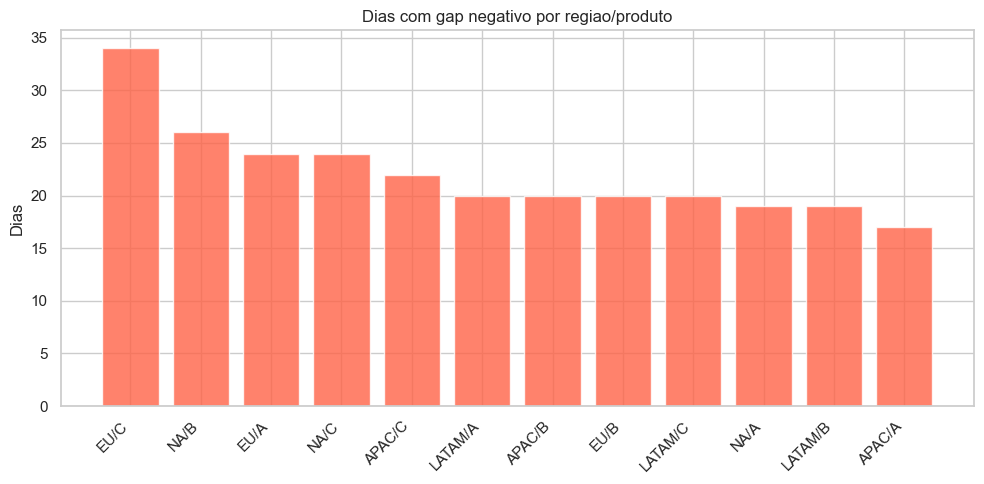

In [9]:
gap['rotulo'] = gap['region'] + '/' + gap['product']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(gap)), gap['dias_gap_negativo'], color='tomato', alpha=0.8)
ax.set_xticks(range(len(gap)))
ax.set_xticklabels(gap['rotulo'], rotation=45, ha='right')
ax.set_title('Dias com gap negativo por regiao/produto')
ax.set_ylabel('Dias')
plt.tight_layout()
plt.show()

## Conclusoes

| Dimensao | Principal achado |
|---|---|
| OTIF | 17,5% geral, problema sistemico, nao localizado |
| Atraso | Mediana de 2 dias, P90 de 10 dias, cauda longa de atrasos graves |
| Stockout | EU lidera em dias de ruptura, especialmente produtos A e C |
| Overflow | LATAM acumula excesso de estoque simultaneamente |
| Producao | Utilizacao media abaixo de 1.0, mas ~22% dos dias com over-capacity em P_NA |
| Balanco | Gaps negativos cronicos indicam desalinhamento estrutural entre oferta e demanda |

Os dados da camada gold sustentam a analise de insights e recomendacoes no notebook `insights.ipynb`.

In [10]:
conn.close()